## Load the packages

In [18]:
from typing import TypedDict, Optional
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt
from langgraph.checkpoint.memory import InMemorySaver

from pydantic import BaseModel
from typing import Literal

## Configure logger and OpenAI

In [19]:
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
checkpointer = InMemorySaver()

import logging

logger = logging.getLogger("library_agent")

logger.setLevel(logging.INFO)

handler = logging.StreamHandler()
formatter = logging.Formatter(
    "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

handler.setFormatter(formatter)

logger.addHandler(handler)

## Define the agent and intent schema

In [ ]:
class AgentState(TypedDict):
    user_input: str
    username: Optional[str]
    intent: Optional[str] # "info" | "request" | "complaint"
    response: Optional[str]
    retrieved_docs: Optional[list]

class IntentClassification(BaseModel):
    intent: Literal["info", "request", "complaint"]

In [21]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from utils import get_info

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

documents = get_info()

vector_store = FAISS.from_documents(
    documents,
    embeddings
)

In [22]:
llm_mini = llm
llm_nano = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

In [23]:
prompt1 = """
    Classify the user input info one of the three categories:
    1. info
    2. complaint
    3. request

    Input: {user_input}
    Respond with only one word: info, complaint, request
    info - User has some query related to the library
        Sample: 
            1 Who manages the library?
            2 Does the library have technology books?
            
    request - User is making some request 
        Sample:
            1 I want to reserve a book.
            2 I would like to register for a library membership.

    complaint - User wants to register some complaint
        Sample:
            1 The digital library is unavailable.
            2 My account shows the wrong due date.
    Note: These are queries related to a library.
    """

In [24]:
llm = llm_mini
prompt = prompt1

In [52]:
async def classify_intent(state):
    structured_llm = llm.with_structured_output(IntentClassification)
    result = await structured_llm.ainvoke(
        prompt.format(user_input=state["user_input"])
    )
    state["intent"] = result.intent
    return state

In [53]:
def info_node(state: AgentState):
    query = state["user_input"]

    # Retrieve top 5 relevant documents from FAISS
    results = vector_store.similarity_search(
        query,
        k=5
    )

    # Store retrieved documents in state
    state["retrieved_docs"] = results

    return state

In [ ]:
async def generation_node(state: AgentState):

    context = "\n\n".join(
        doc.page_content
        for doc in state["retrieved_docs"]
    )

    prompt = f"""
You are a helpful assistant for a public library.

Answer the user's question using ONLY the provided context.

If the answer cannot be found in the context, say that you
don't have enough information to answer.

Context:
{context}

Question:
{state["user_input"]}

Answer:
"""
    result = await llm.ainvoke(prompt)

    state["response"] = result.content

    return state

In [55]:
def route_intent(state: AgentState):
    return state["intent"]

In [56]:
def handle_request(state: AgentState):
    logger.info(
        "Library request received | user=%s | request=%s",
        state.get("username"),
        state["user_input"]
    )

    state["response"] = (
        "Your request has been received and will be processed."
    )

    return state

In [57]:
def handle_complaint(state: AgentState):
    logger.warning(
        "Library complaint received | user=%s | complaint=%s",
        state.get("username"),
        state["user_input"]
    )

    state["response"] = (
        "Your complaint has been recorded and will be reviewed."
    )

    return state

## Build the graph

In [58]:
from langgraph.graph import StateGraph, END

graph = StateGraph(AgentState)

graph.add_node("classify_intent", classify_intent)
graph.add_node("handle_request", handle_request)
graph.add_node("handle_complaint", handle_complaint)
graph.add_node("info_node", info_node)
graph.add_node("generation_node", generation_node)

graph.set_entry_point("classify_intent")

graph.add_conditional_edges(
    "classify_intent",
    route_intent,
    {
        "request": "handle_request",
        "complaint": "handle_complaint",
        "info": "info_node"
    })


graph.add_edge("info_node", "generation_node")
graph.add_edge("generation_node", END)
graph.add_edge("handle_request", END)
graph.add_edge("handle_complaint", END)

In [59]:
app = graph.compile()

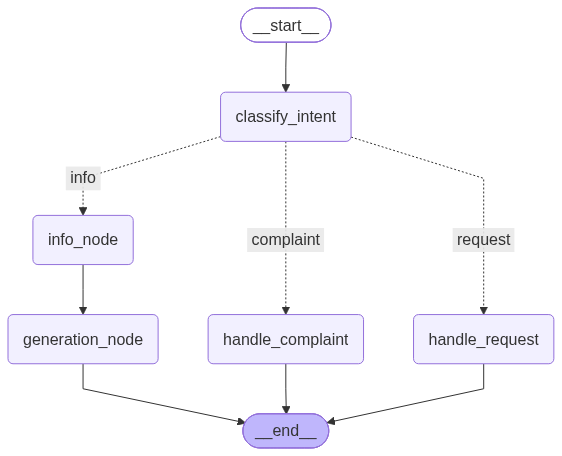

In [36]:
app

In [47]:
result = await app.ainvoke({
    "user_input": "My library card is not working.",
    "username": "vikas",
    "intent": None,
    "response": None,
    "reteieved_docs": None
})

2026-09-17 17:10:06,941 - library_agent - WARNING - Library complaint received | user=vikas | complaint=My library card is not working.
2026-09-17 17:10:06,941 - library_agent - WARNING - Library complaint received | user=vikas | complaint=My library card is not working.


In [48]:
result

{'user_input': 'My library card is not working.',
 'username': 'vikas',
 'intent': 'complaint',
 'response': 'Your complaint has been recorded and will be reviewed.',
 'reteieved_docs': None}

In [64]:
result = await app.ainvoke({
    "user_input": "What is your policy on weekend study?",
    "username": "vikas",
    "intent": None,
    "response": None,
    "reteieved_docs": None
})

In [70]:
result

{'user_input': 'What is your policy on weekend study?',
 'username': 'vikas',
 'intent': 'info',
 'response': 'Students may use weekends for longer study sessions, revision, mock tests, and planning for the upcoming week. Weekend occupancy can differ from weekday occupancy, particularly during examination seasons.',
 'retrieved_docs': [Document(id='4f8a187a-9f5b-4cce-b33d-c488fa473403', metadata={'source': 'C:\\Users\\vikas\\Documents\\Agents-RAG\\local-library\\app\\data.txt', 'paragraph': 23}, page_content='22. Weekend Study\nStudents may use weekends for longer study sessions, revision, mock tests, and planning for the upcoming week. Weekend occupancy can differ from weekday occupancy, particularly during examination seasons.'),
  Document(id='6044e11f-3135-4cd7-b8d3-20804ec50599', metadata={'source': 'C:\\Users\\vikas\\Documents\\Agents-RAG\\local-library\\app\\data.txt', 'paragraph': 22}, page_content='21. Evening Study\nEvening study sessions may be useful for students who attend

## Evaluations

In [47]:
routing_eval_data = [
  {
    "user_input": "Can I renew my book?",
    "expected_output": "info"
  },
  {
    "user_input": "Please renew my book.",
    "expected_output": "request"
  },
  {
    "user_input": "Why can't I renew my book?",
    "expected_output": "complaint"
  },
  {
    "user_input": "Is it possible to reserve a book?",
    "expected_output": "info"
  },
  {
    "user_input": "Reserve this book for me.",
    "expected_output": "request"
  },
  {
    "user_input": "I tried to reserve this book but the system won't let me.",
    "expected_output": "complaint"
  },
  {
    "user_input": "How do I get a library card?",
    "expected_output": "info"
  },
  {
    "user_input": "I need a library card.",
    "expected_output": "request"
  },
  {
    "user_input": "My library card isn't being accepted.",
    "expected_output": "complaint"
  },
  {
    "user_input": "Can you tell me whether my membership is still active?",
    "expected_output": "info"
  },
  {
    "user_input": "Please renew my membership.",
    "expected_output": "request"
  },
  {
    "user_input": "My membership was renewed but my account still says expired.",
    "expected_output": "complaint"
  }
]

In [48]:
import asyncio


async def routing_evaluation(router):
    async def evaluate_item(item):
        state: AgentState = {
            "user_input": item["user_input"]
        }

        intent = await router(state)

        return {
            "user_input": item["user_input"],
            "expected": item["expected_output"],
            "predicted": intent["intent"]
        }

    results = await asyncio.gather(
        *(evaluate_item(item) for item in routing_eval_data)
    )

    return results

## Test performance for prompts 

In [56]:
results = await routing_evaluation(classify_intent)

In [57]:
y_true = [x["expected"] for x in results]
y_pred = [x["predicted"] for x in results]
y_true, y_pred

(['info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint'],
 ['request',
  'request',
  'info',
  'request',
  'request',
  'complaint',
  'request',
  'request',
  'complaint',
  'request',
  'request',
  'complaint'])

## Confusion Matrix

In [79]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["info", "request", "complaint"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print(cm_df)

                  Predicted info  Predicted request  Predicted complaint
Actual info                    0                  4                    0
Actual request                 0                  4                    0
Actual complaint               1                  0                    3


In [71]:
llm = llm_nano

In [72]:
results = await routing_evaluation(classify_intent)

In [73]:
y_true = [x["expected"] for x in results]
y_pred = [x["predicted"] for x in results]
y_true, y_pred

(['info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint'],
 ['request',
  'request',
  'request',
  'request',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint'])

In [74]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["info", "request", "complaint"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print(cm_df)

                  Predicted info  Predicted request  Predicted complaint
Actual info                    2                  2                    0
Actual request                 0                  4                    0
Actual complaint               0                  1                    3


In [75]:
prompt2 = """
    You are an intent classifier for a public library AI assistant.
    
    Your task is to classify the user's message into exactly ONE of these intents:
    
    1. INFO
       The user wants information, an explanation, or an answer to a question.
       They are NOT asking the library to perform an action.
    
       Examples:
       - "What time does the library open?"
       - "Where is the library located?"
       - "Do you have books on Python?"
       - "Can I renew a book?"
       - "How do I get a library card?"
       - "Is book reservation available?"
    
    2. REQUEST
       The user wants the library or library system to perform an action
       on their behalf.
    
       Examples:
       - "Reserve this book for me."
       - "Please renew my book."
       - "I want to register for membership."
       - "Return this book for me."
       - "Please update my phone number."
       - "Cancel my book reservation."
    
    3. COMPLAINT
       The user is reporting a problem, failure, error, dissatisfaction,
       or something that went wrong with the library or its services.
    
       Examples:
       - "My library card is not working."
       - "I cannot log into my account."
       - "I tried to reserve a book but it failed."
       - "I returned my book but it still shows as borrowed."
       - "The library website is not working."
       - "The staff were rude to me."
    
    IMPORTANT RULES:
    
    - If the user is asking whether something is possible, available, allowed,
      or how something works, classify it as INFO.
    - If the user is explicitly asking the library to DO something, classify it
      as REQUEST.
    - If the user says that something is broken, failed, incorrect, unavailable,
      or did not work as expected, classify it as COMPLAINT.
    - Do not classify based only on keywords. Consider the user's actual intent.
    - A question about performing an action is INFO, not REQUEST.
    - An instruction to perform an action is REQUEST.
    - A failed attempt to perform an action is COMPLAINT.
    
    For example:
    
    "Can I renew my book?"
    → INFO
    
    "How can I renew my book?"
    → INFO
    
    "Please renew my book."
    → REQUEST
    
    "Renew my book."
    → REQUEST
    
    "I tried to renew my book but it failed."
    → COMPLAINT
    
    "Why can't I renew my book?"
    → COMPLAINT
    
    User message:
    {user_input}
    """

In [76]:
prompt = prompt2

In [77]:
results = await routing_evaluation(classify_intent)

In [78]:
y_true = [x["expected"] for x in results]
y_pred = [x["predicted"] for x in results]
y_true, y_pred

(['info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint'],
 ['info',
  'request',
  'complaint',
  'info',
  'request',
  'complaint',
  'info',
  'info',
  'complaint',
  'info',
  'request',
  'complaint'])

In [79]:
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["info", "request", "complaint"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print(cm_df)

                  Predicted info  Predicted request  Predicted complaint
Actual info                    4                  0                    0
Actual request                 1                  3                    0
Actual complaint               0                  0                    4


## Retreival evaluation

In [71]:
rag_eval_data = [
    {
        "user_input": "what is your weekend policy for study?",
        "expected_paragraph": 23
    },
    {
        "user_input": "what is your policy on Mobile Phone Use?",
        "expected_paragraph": 25
    },
    {
        "user_input": "can students use the library on weekends?",
        "expected_paragraph": 23
    }
]

In [72]:
def evaluate_retrieval(eval_data, k=5):
    results = []

    for item in eval_data:

        docs = vector_store.similarity_search(
            item["user_input"],
            k=k
        )

        retrieved_paragraphs = [
            doc.metadata["paragraph"]
            for doc in docs
        ]

        hit = item["expected_paragraph"] in retrieved_paragraphs

        results.append({
            "user_input": item["user_input"],
            "expected_paragraph": item["expected_paragraph"],
            "retrieved_paragraphs": retrieved_paragraphs,
            "hit": hit
        })

    return results

In [73]:
results = evaluate_retrieval(rag_eval_data, k=5)

for result in results:
    print(result)

{'user_input': 'what is your weekend policy for study?', 'expected_paragraph': 23, 'retrieved_paragraphs': [23, 22, 21, 8, 53], 'hit': True}
{'user_input': 'what is your policy on Mobile Phone Use?', 'expected_paragraph': 25, 'retrieved_paragraphs': [25, 88, 90, 34, 24], 'hit': True}
{'user_input': 'can students use the library on weekends?', 'expected_paragraph': 23, 'retrieved_paragraphs': [78, 23, 20, 8, 22], 'hit': True}
